In [1]:
!pip install -q torch torchvision scikit-learn pandas matplotlib tqdm pillow

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from torchvision.models import Swin_T_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [3]:
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
PROCESSED_BASE_DIR = "/content/drive/MyDrive/TongueImagediabetes/data/processed_segmented_wb"

DIABETES_DIR = os.path.join(PROCESSED_BASE_DIR, "diabetes")
NONDIABETES_DIR = os.path.join(PROCESSED_BASE_DIR, "nondiabetes")

print("Diabetes dir exists:", os.path.exists(DIABETES_DIR))
print("Non-diabetes dir exists:", os.path.exists(NONDIABETES_DIR))

Diabetes dir exists: True
Non-diabetes dir exists: True


In [6]:
def build_dataframe(diabetes_dir, nondiabetes_dir):
    rows = []

    for img_path in sorted(Path(diabetes_dir).glob("*")):
        if img_path.suffix.lower() in [".png", ".jpg", ".jpeg"]:
            rows.append({
                "image_path": str(img_path),
                "label": 1,
                "label_name": "diabetes"
            })

    for img_path in sorted(Path(nondiabetes_dir).glob("*")):
        if img_path.suffix.lower() in [".png", ".jpg", ".jpeg"]:
            rows.append({
                "image_path": str(img_path),
                "label": 0,
                "label_name": "nondiabetes"
            })

    return pd.DataFrame(rows)

df = build_dataframe(DIABETES_DIR, NONDIABETES_DIR)

print("Total samples:", len(df))
print(df["label_name"].value_counts())
df.head()

Total samples: 954
label_name
nondiabetes    519
diabetes       435
Name: count, dtype: int64


,image_path,label,label_name
0,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes
1,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes
2,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes
3,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes
4,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes


In [7]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["label_name"].value_counts())

print("\nVal distribution:")
print(val_df["label_name"].value_counts())

print("\nTest distribution:")
print(test_df["label_name"].value_counts())

Train: 667
Val: 143
Test: 144

Train distribution:
label_name
nondiabetes    363
diabetes       304
Name: count, dtype: int64

Val distribution:
label_name
nondiabetes    78
diabetes       65
Name: count, dtype: int64

Test distribution:
label_name
nondiabetes    78
diabetes       66
Name: count, dtype: int64


In [8]:
AUG_CSV_PATH = "/content/drive/MyDrive/TongueImagediabetes/data/acgan_outputs/aug_train_df.csv"
aug_train_df = pd.read_csv(AUG_CSV_PATH)

print("Original train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("\nAugmented train:", len(aug_train_df))
print(aug_train_df["label_name"].value_counts())

Original train: 667
Val: 143
Test: 144

Augmented train: 1067
label_name
nondiabetes    563
diabetes       504
Name: count, dtype: int64


In [9]:
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 2

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
class TongueDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = row["image_path"]
        label = row["label"]

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)
        return image, label

In [12]:
train_dataset = TongueDataset(aug_train_df, transform=train_transform)
val_dataset = TongueDataset(val_df, transform=eval_transform)
test_dataset = TongueDataset(test_df, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 67
Val batches: 9
Test batches: 9


In [13]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Sample labels:", labels[:8])

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
Sample labels: tensor([0., 1., 0., 1., 0., 0., 1., 0.])


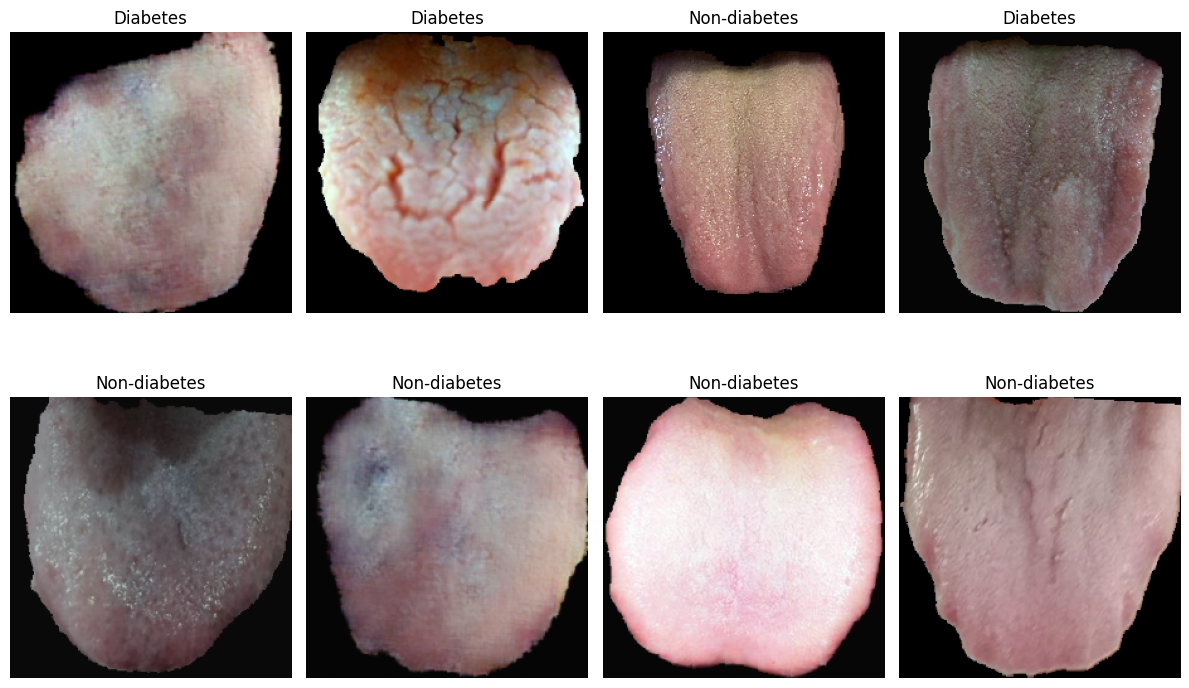

In [14]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_tensor = img_tensor.cpu() * std + mean
    img_tensor = torch.clamp(img_tensor, 0, 1)
    return img_tensor

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title("Diabetes" if labels[i].item() == 1 else "Non-diabetes")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
weights = Swin_T_Weights.DEFAULT
model = models.swin_t(weights=weights)
print(model)

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:01<00:00, 94.7MB/s]


SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (proj): Linear(in_features=96, out_features=96, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=384, out_features=96, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock(
       

In [16]:
in_features = model.head.in_features
model.head = nn.Linear(in_features, 1)

model = model.to(DEVICE)
print(model.head)

Linear(in_features=768, out_features=1, bias=True)


In [17]:
for param in model.parameters():
    param.requires_grad = False

for param in model.head.parameters():
    param.requires_grad = True

In [18]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("Trainable params:", trainable_params)
print("Total params:", total_params)

Trainable params: 769
Total params: 27520123


In [19]:
class_counts = aug_train_df["label"].value_counts().sort_index()
num_negative = class_counts[0]
num_positive = class_counts[1]

pos_weight = torch.tensor([num_negative / num_positive], dtype=torch.float32).to(DEVICE)
print("pos_weight:", pos_weight.item())

pos_weight: 1.1170635223388672


In [20]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.head.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [21]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(logits).detach().cpu().numpy().ravel()
        all_probs.extend(probs)
        all_labels.extend(labels.detach().cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader.dataset)
    preds = (np.array(all_probs) >= 0.5).astype(int)

    acc = accuracy_score(all_labels, preds)
    precision = precision_score(all_labels, preds, zero_division=0)
    recall = recall_score(all_labels, preds, zero_division=0)
    f1 = f1_score(all_labels, preds, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs)

    return epoch_loss, acc, precision, recall, f1, auc

In [22]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader.dataset)
    preds = (np.array(all_probs) >= 0.5).astype(int)

    acc = accuracy_score(all_labels, preds)
    precision = precision_score(all_labels, preds, zero_division=0)
    recall = recall_score(all_labels, preds, zero_division=0)
    f1 = f1_score(all_labels, preds, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs)

    return epoch_loss, acc, precision, recall, f1, auc, np.array(all_labels), np.array(all_probs)

In [25]:
EPOCHS_HEAD = 10

history = {
    "train_loss": [],
    "train_auc": [],
    "val_loss": [],
    "val_auc": []
}

best_val_auc = 0.0
best_model_path = "/content/drive/MyDrive/TongueImagediabetes/swin_tiny_W_acgan_best_head.pth"

In [26]:
for epoch in range(EPOCHS_HEAD):
    print(f"\nEpoch {epoch+1}/{EPOCHS_HEAD}")

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    train_loss, train_acc, train_precision, train_recall, train_f1, train_auc = train_metrics

    val_metrics = evaluate(model, val_loader, criterion, DEVICE)
    val_loss, val_acc, val_precision, val_recall, val_f1, val_auc, _, _ = val_metrics

    history["train_loss"].append(train_loss)
    history["train_auc"].append(train_auc)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)

    print(f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   AUC: {val_auc:.4f} | Val   F1: {val_f1:.4f}")

    scheduler.step(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), best_model_path)
        print("Best head model saved.")


Epoch 1/10


Train Loss: 0.5864 | Train AUC: 0.7962 | Train F1: 0.6885
Val   Loss: 0.4351 | Val   AUC: 0.9185 | Val   F1: 0.8154
Best head model saved.

Epoch 2/10


Train Loss: 0.5566 | Train AUC: 0.8159 | Train F1: 0.7099
Val   Loss: 0.4212 | Val   AUC: 0.9203 | Val   F1: 0.8130
Best head model saved.

Epoch 3/10


Train Loss: 0.5296 | Train AUC: 0.8333 | Train F1: 0.7331
Val   Loss: 0.3847 | Val   AUC: 0.9302 | Val   F1: 0.8092
Best head model saved.

Epoch 4/10


Train Loss: 0.5074 | Train AUC: 0.8509 | Train F1: 0.7462
Val   Loss: 0.3765 | Val   AUC: 0.9278 | Val   F1: 0.8217

Epoch 5/10


...

Train Loss: 0.4960 | Train AUC: 0.8553 | Train F1: 0.7389
Val   Loss: 0.3514 | Val   AUC: 0.9412 | Val   F1: 0.8444
Best head model saved.

Epoch 7/10


Train Loss: 0.4974 | Train AUC: 0.8532 | Train F1: 0.7536
Val   Loss: 0.3441 | Val   AUC: 0.9410 | Val   F1: 0.8217

Epoch 8/10


Train Loss: 0.4958 | Train AUC: 0.8542 | Train F1: 0.7532
Val   Loss: 0.3376 | Val   AUC: 0.9426 | Val   F1: 0.8467
Best head model saved.

Epoch 9/10


Train Loss: 0.4790 | Train AUC: 0.8606 | Train F1: 0.7433
Val   Loss: 0.3352 | Val   AUC: 0.9438 | Val   F1: 0.8593
Best head model saved.

Epoch 10/10


Train Loss: 0.4872 | Train AUC: 0.8596 | Train F1: 0.7520
Val   Loss: 0.3323 | Val   AUC: 0.9483 | Val   F1: 0.8529
Best head model saved.


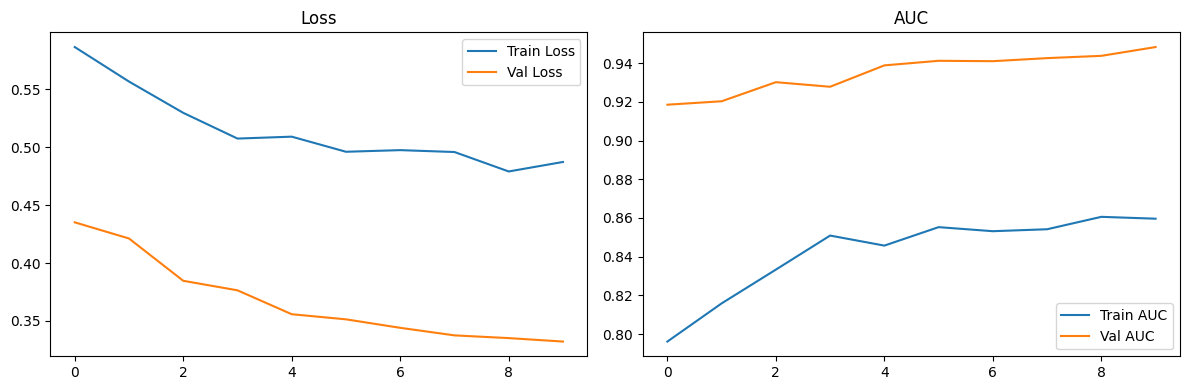

In [27]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(history["train_auc"], label="Train AUC")
plt.plot(history["val_auc"], label="Val AUC")
plt.legend()
plt.title("AUC")

plt.tight_layout()
plt.show()

In [28]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()
print("Best head model loaded.")

Best head model loaded.


In [29]:
for param in model.parameters():
    param.requires_grad = False

for param in model.features[-1].parameters():
    param.requires_grad = True

for param in model.norm.parameters():
    param.requires_grad = True

for param in model.head.parameters():
    param.requires_grad = True

In [30]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable params after unfreezing final stage:", trainable_params)

Trainable params after unfreezing final stage: 14186161


In [31]:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

EPOCHS_FINE = 10
best_finetuned_model_path = "/content/drive/MyDrive/TongueImagediabetes/swin_tiny_W_acgan_best_finetuned.pth"
best_val_auc = 0.0

In [32]:
for epoch in range(EPOCHS_FINE):
    print(f"\nFine-tuning Epoch {epoch+1}/{EPOCHS_FINE}")

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    train_loss, train_acc, train_precision, train_recall, train_f1, train_auc = train_metrics

    val_metrics = evaluate(model, val_loader, criterion, DEVICE)
    val_loss, val_acc, val_precision, val_recall, val_f1, val_auc, _, _ = val_metrics

    print(f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   AUC: {val_auc:.4f} | Val   F1: {val_f1:.4f}")

    scheduler.step(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), best_finetuned_model_path)
        print("Best fine-tuned model saved.")


Fine-tuning Epoch 1/10


Train Loss: 0.5052 | Train AUC: 0.8387 | Train F1: 0.7303
Val   Loss: 0.2407 | Val   AUC: 0.9690 | Val   F1: 0.9062
Best fine-tuned model saved.

Fine-tuning Epoch 2/10


Train Loss: 0.4274 | Train AUC: 0.8810 | Train F1: 0.7757
Val   Loss: 0.1593 | Val   AUC: 0.9868 | Val   F1: 0.9394
Best fine-tuned model saved.

Fine-tuning Epoch 3/10


Train Loss: 0.3931 | Train AUC: 0.8979 | Train F1: 0.7793
Val   Loss: 0.1409 | Val   AUC: 0.9895 | Val   F1: 0.9302
Best fine-tuned model saved.

Fine-tuning Epoch 4/10


Train Loss: 0.3680 | Train AUC: 0.9098 | Train F1: 0.7928
Val   Loss: 0.3356 | Val   AUC: 0.9870 | Val   F1: 0.8514

Fine-tuning Epoch 5/10


...

Train Loss: 0.3342 | Train AUC: 0.9280 | Train F1: 0.8247
Val   Loss: 0.1086 | Val   AUC: 0.9941 | Val   F1: 0.9545
Best fine-tuned model saved.

Fine-tuning Epoch 7/10


Train Loss: 0.2967 | Train AUC: 0.9454 | Train F1: 0.8360
Val   Loss: 0.1568 | Val   AUC: 0.9925 | Val   F1: 0.9466

Fine-tuning Epoch 8/10


Train Loss: 0.2924 | Train AUC: 0.9428 | Train F1: 0.8348
Val   Loss: 0.1393 | Val   AUC: 0.9966 | Val   F1: 0.9701
Best fine-tuned model saved.

Fine-tuning Epoch 9/10


Train Loss: 0.3075 | Train AUC: 0.9398 | Train F1: 0.8356
Val   Loss: 0.1469 | Val   AUC: 0.9961 | Val   F1: 0.9559

Fine-tuning Epoch 10/10


Train Loss: 0.2932 | Train AUC: 0.9497 | Train F1: 0.8560
Val   Loss: 0.0785 | Val   AUC: 0.9980 | Val   F1: 0.9701
Best fine-tuned model saved.


In [33]:
model.load_state_dict(torch.load(best_finetuned_model_path, map_location=DEVICE))
model.eval()
print("Best fine-tuned model loaded.")

Best fine-tuned model loaded.


In [34]:
from sklearn.metrics import f1_score, recall_score, precision_score

def find_best_threshold(y_true, y_probs, metric="f1"):
    thresholds = np.arange(0.10, 0.91, 0.01)

    best_threshold = 0.50
    best_score = -1
    results = []

    for t in thresholds:
        y_pred = (y_probs >= t).astype(int)

        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == "recall":
            score = recall_score(y_true, y_pred, zero_division=0)
        elif metric == "precision":
            score = precision_score(y_true, y_pred, zero_division=0)
        else:
            raise ValueError("metric must be 'f1', 'recall', or 'precision'")

        results.append((t, score))

        if score > best_score:
            best_score = score
            best_threshold = t

    return best_threshold, best_score, results

In [37]:
val_loss, val_acc, val_precision, val_recall, val_f1, val_auc, y_val_true, y_val_probs = evaluate(
    model, val_loader, criterion, DEVICE
)

best_threshold, best_val_f1_at_threshold, threshold_results = find_best_threshold(
    y_val_true,
    y_val_probs,
    metric="f1"
)

print(f"Best threshold from validation set: {best_threshold:.2f}")
print(f"Best validation F1 at this threshold: {best_val_f1_at_threshold:.4f}")

Best threshold from validation set: 0.82
Best validation F1 at this threshold: 0.9924


In [38]:
test_loss, _, _, _, _, _, y_true, y_probs = evaluate(
    model, test_loader, criterion, DEVICE
)

y_pred = (y_probs >= best_threshold).astype(int)

test_acc = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, zero_division=0)
test_recall = recall_score(y_true, y_pred, zero_division=0)
test_f1 = f1_score(y_true, y_pred, zero_division=0)
test_auc = roc_auc_score(y_true, y_probs)

print(f"Chosen Threshold: {best_threshold:.2f}")
print(f"Test Loss:      {test_loss:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-score:  {test_f1:.4f}")
print(f"Test AUC-ROC:   {test_auc:.4f}")

Chosen Threshold: 0.82
Test Loss:      0.2279
Test Accuracy:  0.9444
Test Precision: 0.9833
Test Recall:    0.8939
Test F1-score:  0.9365
Test AUC-ROC:   0.9821


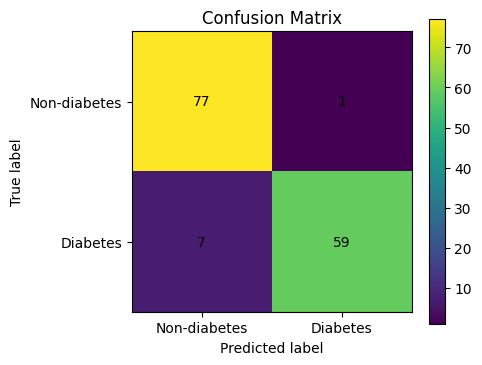

In [39]:
cm = confusion_matrix(y_true, y_pred)
cm

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Non-diabetes", "Diabetes"])
plt.yticks(tick_marks, ["Non-diabetes", "Diabetes"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [40]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["Non-diabetes", "Diabetes"],
    digits=4
))

              precision    recall  f1-score   support

Non-diabetes     0.9167    0.9872    0.9506        78
    Diabetes     0.9833    0.8939    0.9365        66

    accuracy                         0.9444       144
   macro avg     0.9500    0.9406    0.9436       144
weighted avg     0.9472    0.9444    0.9442       144



In [41]:
test_results_df = test_df.copy()
test_results_df["true_label"] = y_true.astype(int)
test_results_df["pred_prob_diabetes"] = y_probs
test_results_df["pred_label"] = y_pred

save_csv_path = "/content/drive/MyDrive/TongueImagediabetes/swin_tiny_W_acgan_test_predictions.csv"
test_results_df.to_csv(save_csv_path, index=False)

print("Saved test predictions to:", save_csv_path)
test_results_df.head()

Saved test predictions to: /content/drive/MyDrive/TongueImagediabetes/swin_tiny_W_acgan_test_predictions.csv


,image_path,label,label_name,true_label,pred_prob_diabetes,pred_label
0,/content/drive/MyDrive/TongueImagediabetes/dat...,0,nondiabetes,0,0.988604,1
1,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes,1,0.501226,0
2,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes,1,0.999956,1
3,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes,1,0.999807,1
4,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes,1,0.592127,0
